In [1]:
# loading libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from joblib import dump

In [2]:
# loading data
data=pd.read_csv(r"C:\Users\Prem\Desktop\ML projects\customer_segmentation.csv")
data

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
10690,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,NaN
10691,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,NaN
10692,467960,Female,No,53,Yes,Entertainment,NaN,Low,2.0,Cat_6,NaN
10693,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,NaN


In [3]:
# making copie of data for safe side
df=data
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
10690,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,NaN
10691,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,NaN
10692,467960,Female,No,53,Yes,Entertainment,NaN,Low,2.0,Cat_6,NaN
10693,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,NaN


In [4]:
# dropping irrelevant columns
df=df.drop(columns=['ID','Segmentation'])

In [6]:
# checking nulls
df.isnull().sum()

Gender                0
Ever_Married        190
Age                   0
Graduated           102
Profession          162
Work_Experience    1098
Spending_Score        0
Family_Size         448
Var_1               108
dtype: int64

In [7]:
# checking duplicates
df.duplicated().sum()

np.int64(1296)

In [8]:
# dropping non-numeric columns
df=df.drop(columns=['Gender','Ever_Married','Graduated','Profession','Spending_Score','Var_1'])

In [9]:
df

,Age,Work_Experience,Family_Size
0,22,1.0,4.0
1,38,NaN,3.0
2,67,1.0,1.0
3,67,0.0,2.0
4,40,NaN,6.0
...,...,...,...
10690,29,9.0,4.0
10691,35,1.0,1.0
10692,53,NaN,2.0
10693,47,1.0,5.0


In [10]:
# handling nulls
df.isnull().sum()

Age                   0
Work_Experience    1098
Family_Size         448
dtype: int64

In [11]:
df['Work_Experience'].unique()

array([ 1., nan,  0.,  4.,  9., 12.,  3., 13.,  5.,  8., 14.,  7.,  2.,
        6., 10., 11.])

In [12]:
df['Work_Experience']=df['Work_Experience'].fillna(df['Work_Experience'].median())

In [13]:
df['Work_Experience'].isnull().sum()

np.int64(0)

In [14]:
df['Family_Size'].unique()

array([ 4.,  3.,  1.,  2.,  6., nan,  5.,  8.,  7.,  9.])

In [15]:
df['Family_Size']=df['Family_Size'].fillna(df['Family_Size'].median())

In [16]:
df['Family_Size'].isnull().sum()

np.int64(0)

In [17]:
df.isnull().sum()

Age                0
Work_Experience    0
Family_Size        0
dtype: int64

In [18]:
df

,Age,Work_Experience,Family_Size
0,22,1.0,4.0
1,38,1.0,3.0
2,67,1.0,1.0
3,67,0.0,2.0
4,40,1.0,6.0
...,...,...,...
10690,29,9.0,4.0
10691,35,1.0,1.0
10692,53,1.0,2.0
10693,47,1.0,5.0


In [19]:
# scaling
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

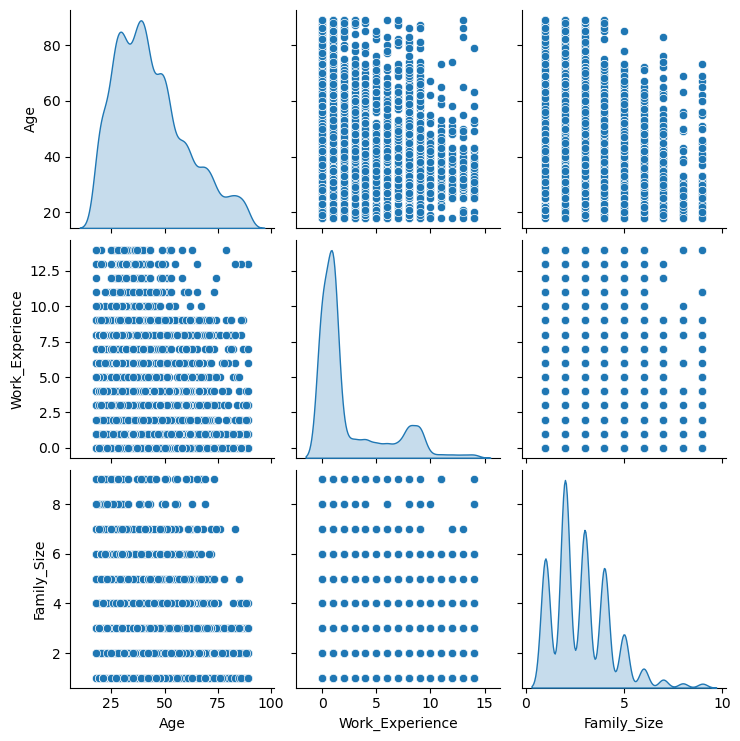

In [20]:
# sns.pairplot(df,hue='') 
sns.pairplot(df,diag_kind='kde')
#sns.pairplot(df,markers=['o', 's', 'D'])
plt.show()

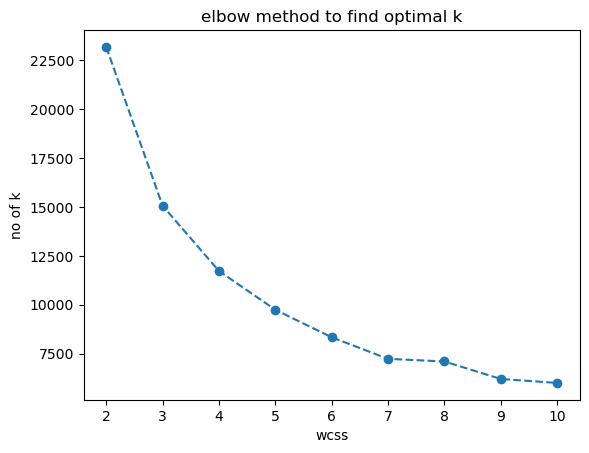

In [21]:
# elbow metcod 
wcss=[] # -within cluster sum of squares
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++',random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)


# visualize
plt.plot(range(2,11),wcss,marker='o',linestyle='--')
plt.title('elbow method to find optimal k')
plt.xlabel('wcss')
plt.ylabel('no of k')
plt.show()    

In [22]:
# silhouette score
scores=[]
for k in range(2,15):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(df_scaled)
    scores=silhouette_score(df_scaled,labels)
    print(f'k={k},silhouette score={scores}')

k=2,silhouette score=0.26455164672106385
k=3,silhouette score=0.3534349392590649
k=4,silhouette score=0.3560975500487788
k=5,silhouette score=0.3352101784880871
k=6,silhouette score=0.3665821616581449
k=7,silhouette score=0.36235497499092384
k=8,silhouette score=0.3269292064776083
k=9,silhouette score=0.32581085147658134
k=10,silhouette score=0.289309858237008
k=11,silhouette score=0.29994735066422934
k=12,silhouette score=0.3035340744769541
k=13,silhouette score=0.3087497092893151
k=14,silhouette score=0.31142796627219804


In [ ]:
# building k-means model
kmeans=KMeans(n_clusters=6,random_state=42)
clusters=kmeans.fit_predict(df_scaled)

In [24]:
df['clusters']=clusters

In [25]:
df

,Age,Work_Experience,Family_Size,clusters
0,22,1.0,4.0,5
1,38,1.0,3.0,5
2,67,1.0,1.0,1
3,67,0.0,2.0,1
4,40,1.0,6.0,2
...,...,...,...,...
10690,29,9.0,4.0,3
10691,35,1.0,1.0,0
10692,53,1.0,2.0,0
10693,47,1.0,5.0,4


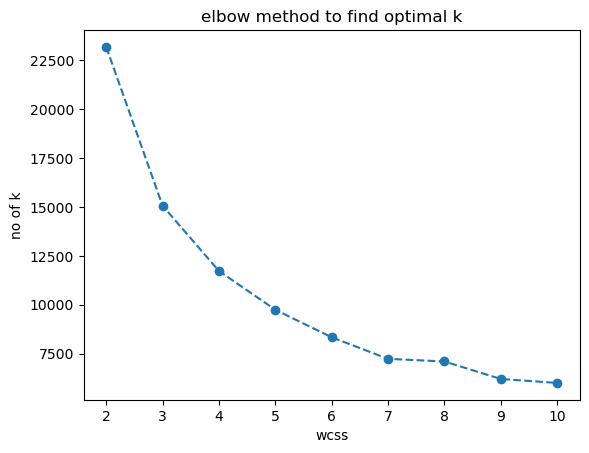

In [26]:
# visulize
plt.plot(range(2,11),wcss,marker='o',linestyle='--')
plt.title('elbow method to find optimal k')
plt.xlabel('wcss')
plt.ylabel('no of k')
plt.show()    

In [27]:
# if data having more than 3 features 
'''
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled) '''# this technique will reduce the dimension of the data

'\nfrom sklearn.decomposition import PCA\n\npca = PCA(n_components=2)\nX_pca = pca.fit_transform(df_scaled) '

In [28]:
dump(kmeans,'kmeans_clustering_algorithm.joblib')

['kmeans_clustering_algorithm.joblib']